In [27]:
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

# -------------------------------
# load processed data (PKL)
# -------------------------------

processed_folder = "/scratch/elena/9Li/results/run1846/processed"
processed_files = sorted(glob(f"{processed_folder}/*.pkl"))

match = re.search(r'run(\d+)', processed_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"


print(f"Found {len(processed_files)} processed files.")

if len(processed_files) > 0:
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)


    dfs = [pd.read_pickle(f) for f in processed_files]
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Total clusters loaded: {len(df_all)}")

    # chi2/ndof
    if 'chi2_ndof' in df_all.columns:
        valid_fits = df_all[df_all['fit_success'] == True]
        print(f"Fit success: {len(valid_fits)}")

Run number: 1846
Found 50 processed files.
Total clusters loaded: 201875
Fit success: 200366


In [28]:
# 1. Ensure the lookup is globally accessible to the modules
# We force it into the module's namespace
functions_bonsai.geo = lookup 

if 'df_all' not in locals():
    print("Error: df_all not found.")
else:
    mask_pre = (df_all['fit_success'] == True) & \
               (df_all['time_rms'] < 3.0) & \
               (df_all['vertex_x'].abs() < 270) & \
               (df_all['vertex_y'].abs() < 270)

    df_to_refine = df_all[mask_pre].copy()
    print(f"Candidates for refinement: {len(df_to_refine)}")

    def refine_pipeline(row):
        # We ensure the module sees the lookup table in every iteration
        functions_bonsai.geo = lookup
        
        times = np.array(row['hit_times_ns'])
        mpmt_ids = np.array(row['hit_slot_ids'])
        pmt_ids = np.array(row['hit_channel_ids'])
        v_init = np.array([row['vertex_x'], row['vertex_y'], row['vertex_z']])
        
        try:
            # STAGE 2: dt-cut
            # Get positions using the 'lookup' we know works in the diagnostic
            x_p, y_p, z_p, _ = functions_bonsai.getxyz(lookup, mpmt_ids, pmt_ids)
            pmt_pos = np.column_stack([x_p, y_p, z_p])
            
            c_n = 29.9792458 / 1.33 
            tof = np.linalg.norm(pmt_pos - v_init, axis=1) / c_n
            
            t_corr = times - tof
            t0_guess = np.median(t_corr)
            dt = t_corr - t0_guess
            
            clean_mask = (np.abs(dt) < 3.0)
            
            if np.sum(clean_mask) < 6:
                return pd.Series([np.nan]*5, index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])

            # STAGE 3: Fine Adjustment
            # Pass the cleaned hits
            vertex = functions_multilateration.run_multilateration_candidate(
                times[clean_mask], mpmt_ids[clean_mask], pmt_ids[clean_mask],
                sigma_t=2.2,
                guess=(v_init[0], v_init[1], v_init[2], t0_guess)
            )
            
            if vertex["success"]:
                # vertex["pulls"] are (dt / sigma_t). To get RMS in ns, multiply by sigma_t (2.2)
                t_rms_final = np.std(vertex["pulls"] * 2.2)
                return pd.Series([vertex['x'], vertex['y'], vertex['z'], t_rms_final, np.sum(clean_mask)], 
                                 index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])
        except:
            pass
        
        return pd.Series([np.nan]*5, index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])

    print("Processing refinement...")
    # Apply and join
    refined_results = df_to_refine.apply(refine_pipeline, axis=1)
    df_final = pd.concat([df_to_refine, refined_results], axis=1)
    
    # Check if we have data now
    valid_count = df_final['t_rms_fine'].notna().sum()
    print(f"Refinement completed. Valid results: {valid_count} / {len(df_to_refine)}")

Candidates for refinement: 159266
Processing refinement...
Refinement completed. Valid results: 157972 / 159266


In [29]:
print("Columns in df_final:", df_final.columns.tolist())
print(f"Total rows: {len(df_final)}")

Columns in df_final: ['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 'spill_id', 'nCLusters_in_spill', 'hit_card_ids', 'hit_slot_ids', 'hit_channel_ids', 'hit_position_ids', 'hit_times_ns', 'hit_charges', 'vertex_x', 'vertex_y', 'vertex_z', 'fit_success', 'n_hits_used', 'time_rms', 'chi2', 'ndof', 'chi2_ndof', 'v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine']
Total rows: 159266


In [30]:
df_final.head()

,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,nCLusters_in_spill,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,...,n_hits_used,time_rms,chi2,ndof,chi2_ndof,v_x_fine,v_y_fine,v_z_fine,t_rms_fine,nhits_fine
1,8.020986e+09,5.571968e+05,22,0,670,"[10, 34, 26, 15, 21, 42, 98, 98, 89, 99, 19, 1...","[61, 78, 60, 58, 64, 80, 100, 100, 89, 90, 41,...","[4, 1, 14, 15, 5, 3, 3, 7, 2, 7, 14, 2, 5, 10,...","[1, 6, 13, 5, 7, 18, 18, 2, 0, 2, 13, 0, 7, 10...","[8020986088.004007, 8020986090.157587, 8020986...",...,22,1.107696,27.175056,18.0,1.509725,39.846227,14.436110,-162.176102,0.676137,21.0
2,8.020998e+09,5.694473e+05,49,0,670,"[10, 10, 25, 25, 35, 26, 23, 83, 80, 80, 73, 4...","[61, 61, 62, 62, 76, 60, 47, 28, 30, 30, 31, 4...","[15, 16, 2, 8, 12, 1, 15, 19, 4, 6, 4, 15, 16,...","[5, 14, 0, 9, 4, 6, 5, 4, 1, 8, 1, 5, 14, 9, 1...","[8020998354.90268, 8020998356.207907, 80209983...",...,44,0.823723,29.856659,40.0,0.746416,11.123700,-33.183346,-81.129025,0.823344,44.0
3,8.021034e+09,6.053448e+05,57,0,670,"[73, 44, 71, 78, 78, 78, 78, 78, 78, 78, 78, 7...","[31, 43, 103, 33, 33, 33, 33, 33, 33, 33, 33, ...","[11, 15, 9, 1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 1...","[11, 5, 3, 6, 0, 18, 1, 2, 9, 3, 10, 11, 4, 12...","[8021034242.182418, 8021034249.055196, 8021034...",...,57,1.542880,135.978819,53.0,2.565638,-198.998172,-163.206341,32.403300,1.073452,56.0
5,8.021270e+09,8.407723e+05,81,0,670,"[21, 20, 36, 89, 111, 44, 44, 107, 99, 113, 87...","[64, 81, 46, 89, 97, 43, 43, 44, 90, 26, 88, 8...","[1, 3, 13, 6, 8, 11, 15, 11, 7, 12, 0, 7, 17, ...","[6, 18, 12, 8, 9, 11, 5, 11, 2, 4, 17, 2, 15, ...","[8021269666.143704, 8021269667.921798, 8021269...",...,81,2.014427,337.094956,77.0,4.377857,-49.821914,-24.893047,-121.770471,0.962169,75.0
6,8.021516e+09,1.087214e+06,26,0,670,"[16, 16, 16, 20, 113, 113, 113, 27, 8, 115, 24...","[73, 73, 73, 81, 26, 26, 26, 2, 84, 57, 71, 87...","[9, 13, 2, 1, 7, 11, 12, 18, 0, 2, 6, 17, 0, 4...","[3, 12, 0, 6, 2, 11, 4, 16, 17, 0, 8, 15, 17, ...","[8021516108.347639, 8021516107.573359, 8021516...",...,26,2.201234,131.218260,22.0,5.964466,44.736925,-49.565353,-110.259579,0.938619,23.0


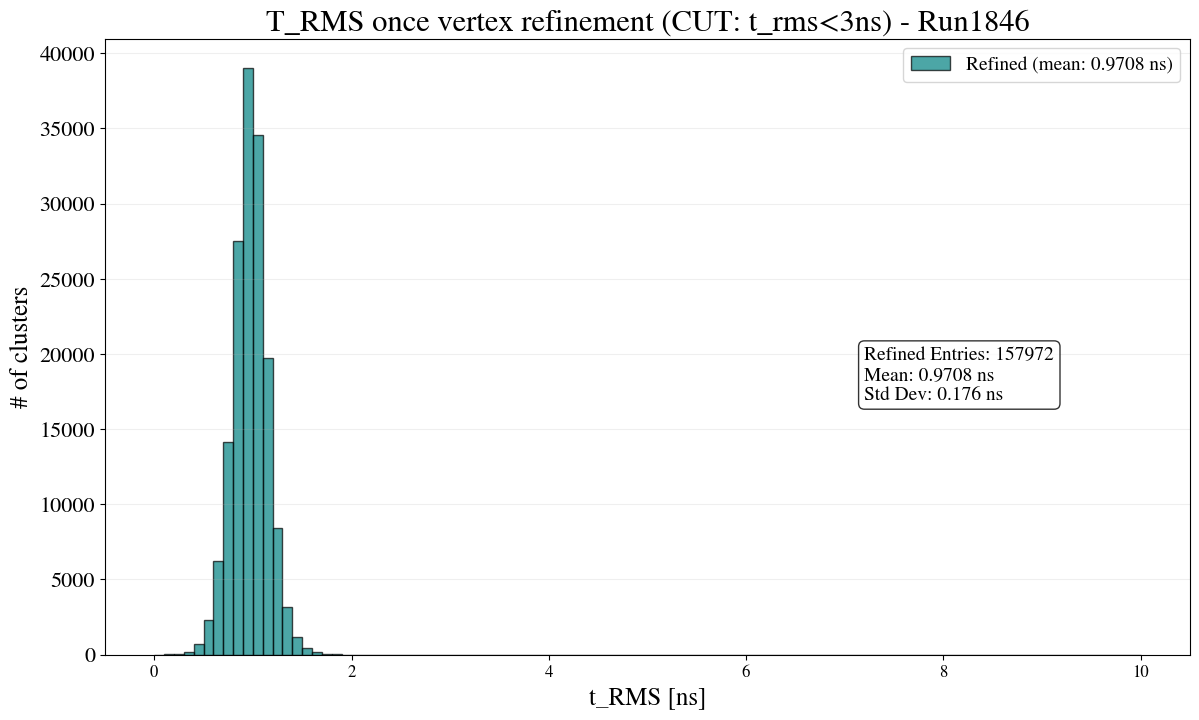

Final refined Mean T_RMS: 0.9708 ns


In [31]:
# 1. Select only the successfully refined clusters
df_plot = df_final[df_final['t_rms_fine'].notna()].copy()

if len(df_plot) == 0:
    print("Zero valid results. Check if the 'guess' or 'clean_mask' logic is too strict.")
else:
    plt.figure(figsize=(14, 8))

    #m1, std1 = df_plot['time_rms'].mean(), df_plot['time_rms'].std()
    m2, std2 = df_plot['t_rms_fine'].mean(), df_plot['t_rms_fine'].std()

    plt.hist(df_plot['t_rms_fine'], bins=100, alpha=0.7, range=[0,10],
             color='teal', label=f'Refined (mean: {m2:.4f} ns)', edgecolor='black')

    plt.title(f"T_RMS once vertex refinement (CUT: t_rms<3ns) - Run{run_number}", fontsize=22)
    plt.xlabel("t_RMS [ns]", fontsize=18)
    plt.ylabel("# of clusters", fontsize=18)
    

    stats_text = (f"Refined Entries: {len(df_plot)}\n"
                  f"Mean: {m2:.4f} ns\n"
                  f"Std Dev: {std2:.3f} ns")
    plt.text(0.7, 0.5, stats_text, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend(loc='upper right', fontsize=14)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

    print(f"Final refined Mean T_RMS: {m2:.4f} ns")

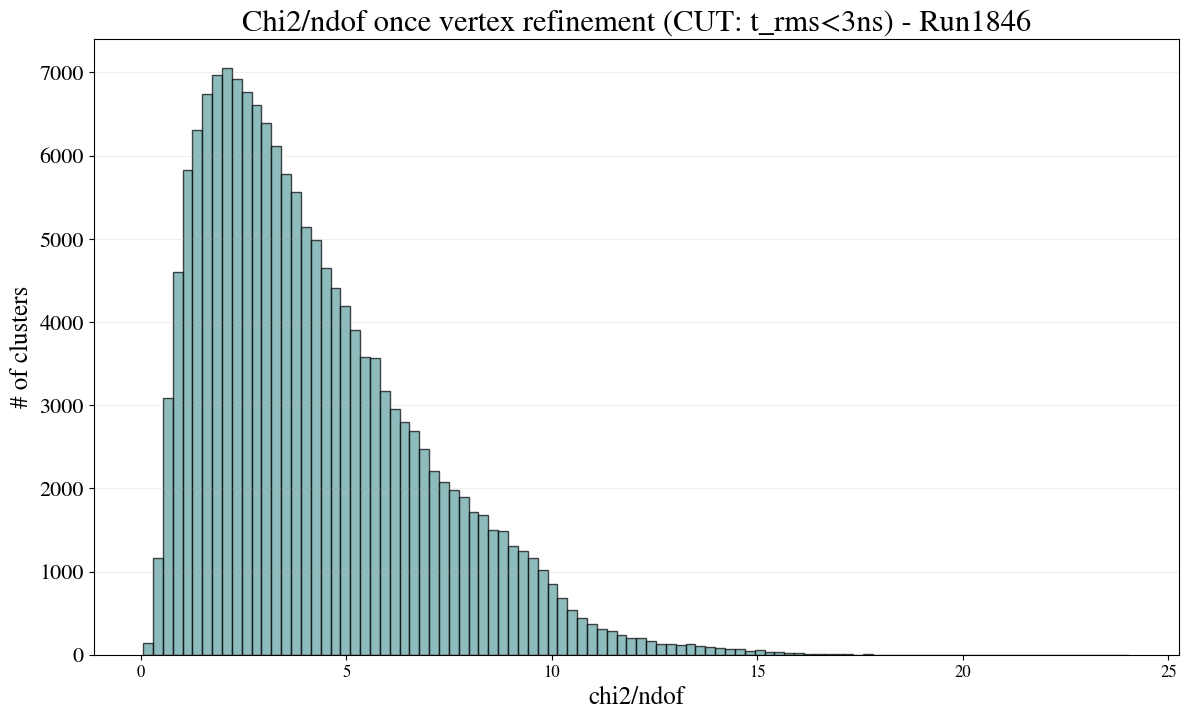

In [32]:
# 1. Select only the successfully refined clusters
df_plot = df_final[df_final['chi2_ndof'].notna()].copy()

if len(df_plot) == 0:
    print("Zero valid results. Check if the 'guess' or 'clean_mask' logic is too strict.")
else:
    plt.figure(figsize=(14, 8))

    plt.hist(df_plot['chi2_ndof'], bins=100, alpha=0.7, color='cadetblue', edgecolor='black')

    plt.title(f"Chi2/ndof once vertex refinement (CUT: t_rms<3ns) - Run{run_number}", fontsize=22)
    plt.xlabel("chi2/ndof", fontsize=18)
    plt.ylabel("# of clusters", fontsize=18)

    plt.grid(axis='y', alpha=0.2)
    plt.show()

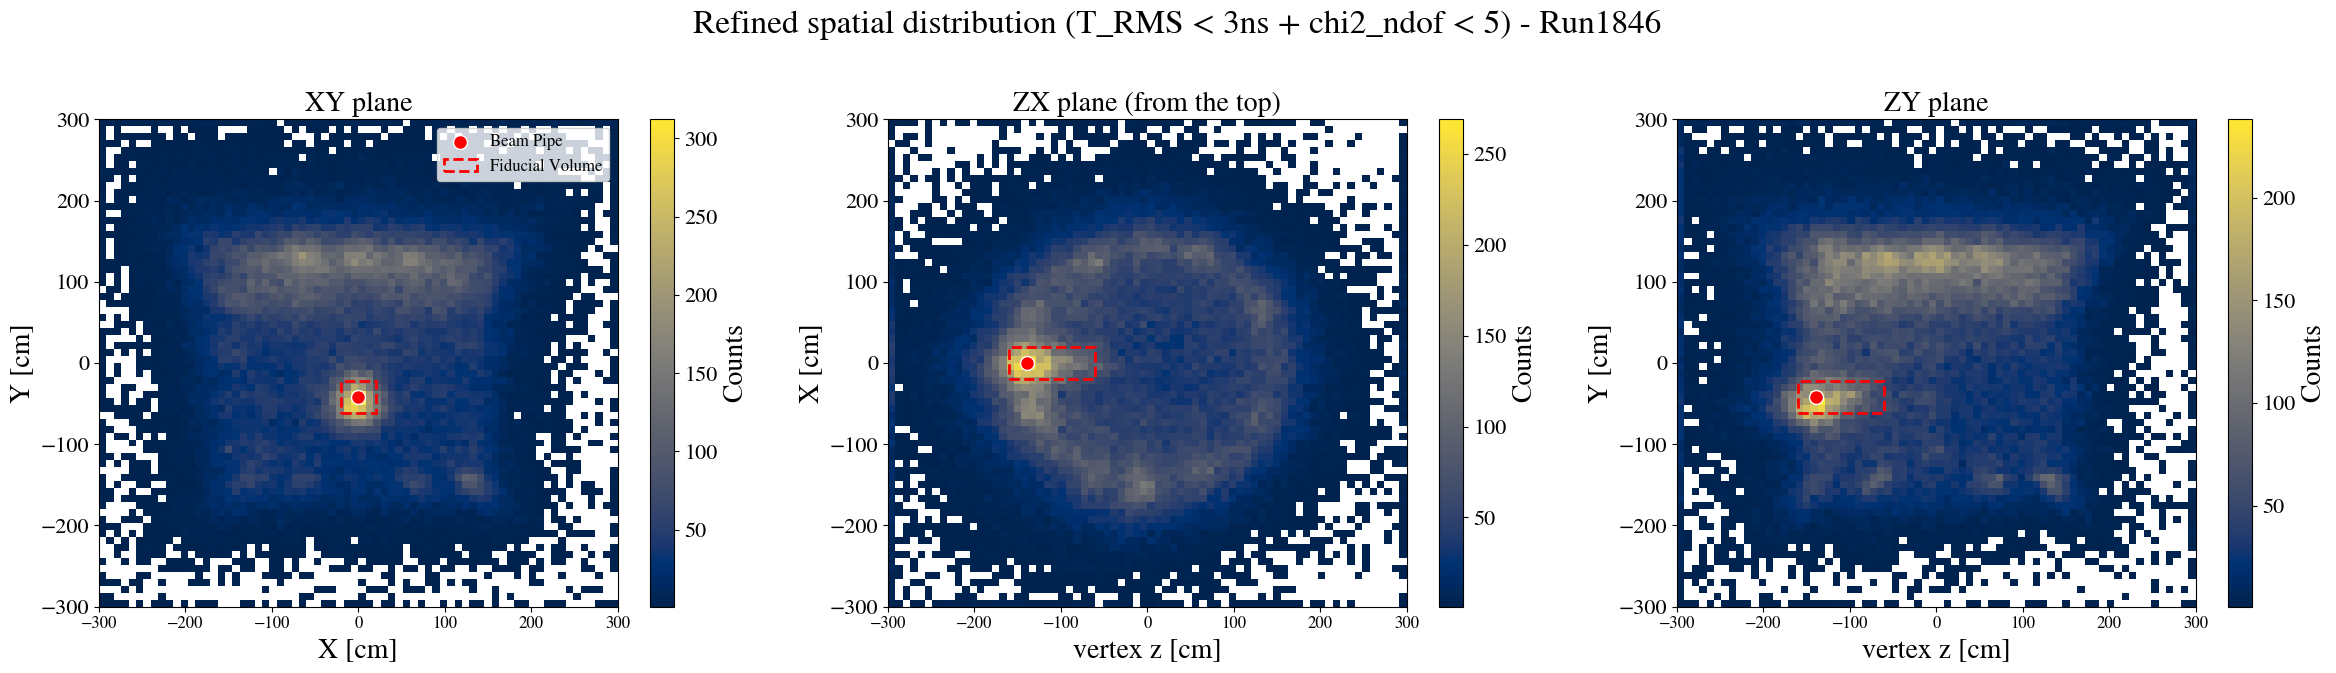

Total clusters analyzed:           201875
Events satisfying mask (refined):  107751
Selection efficiency:              53.38%


In [33]:
import matplotlib.patches as patches

mask_refined = (df_final['v_x_fine'].notna()) & \
               (df_final["chi2_ndof"] < 5) 

df_clean = df_final[mask_refined].copy()

# 2. Setup the figure
fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 

# Limits for the Fiducial Volume (FV) box
x_lims = [-20, 20]
y_lims = [-62, -22]
z_lims = [-160, -60]

box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

# --- XY Plane ---
im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
rect_xy = patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume')
axs[0].add_patch(rect_xy)
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right', fontsize=12)
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# --- ZX Plane ---
im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], bins=70, cmap='cividis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
rect_zx = patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style)
axs[1].add_patch(rect_zx)
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# --- ZY Plane ---
im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
rect_zy = patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style)
axs[2].add_patch(rect_zy)
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

plt.suptitle(f"Refined spatial distribution (T_RMS < 3ns + chi2_ndof < 5) - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()

# --- STATISTICS ---
total_events = len(df_all)
passed_events = len(df_clean)
percentage = (passed_events / total_events) * 100


print(f"Total clusters analyzed:           {total_events}")
print(f"Events satisfying mask (refined):  {passed_events}")
print(f"Selection efficiency:              {percentage:.2f}%")


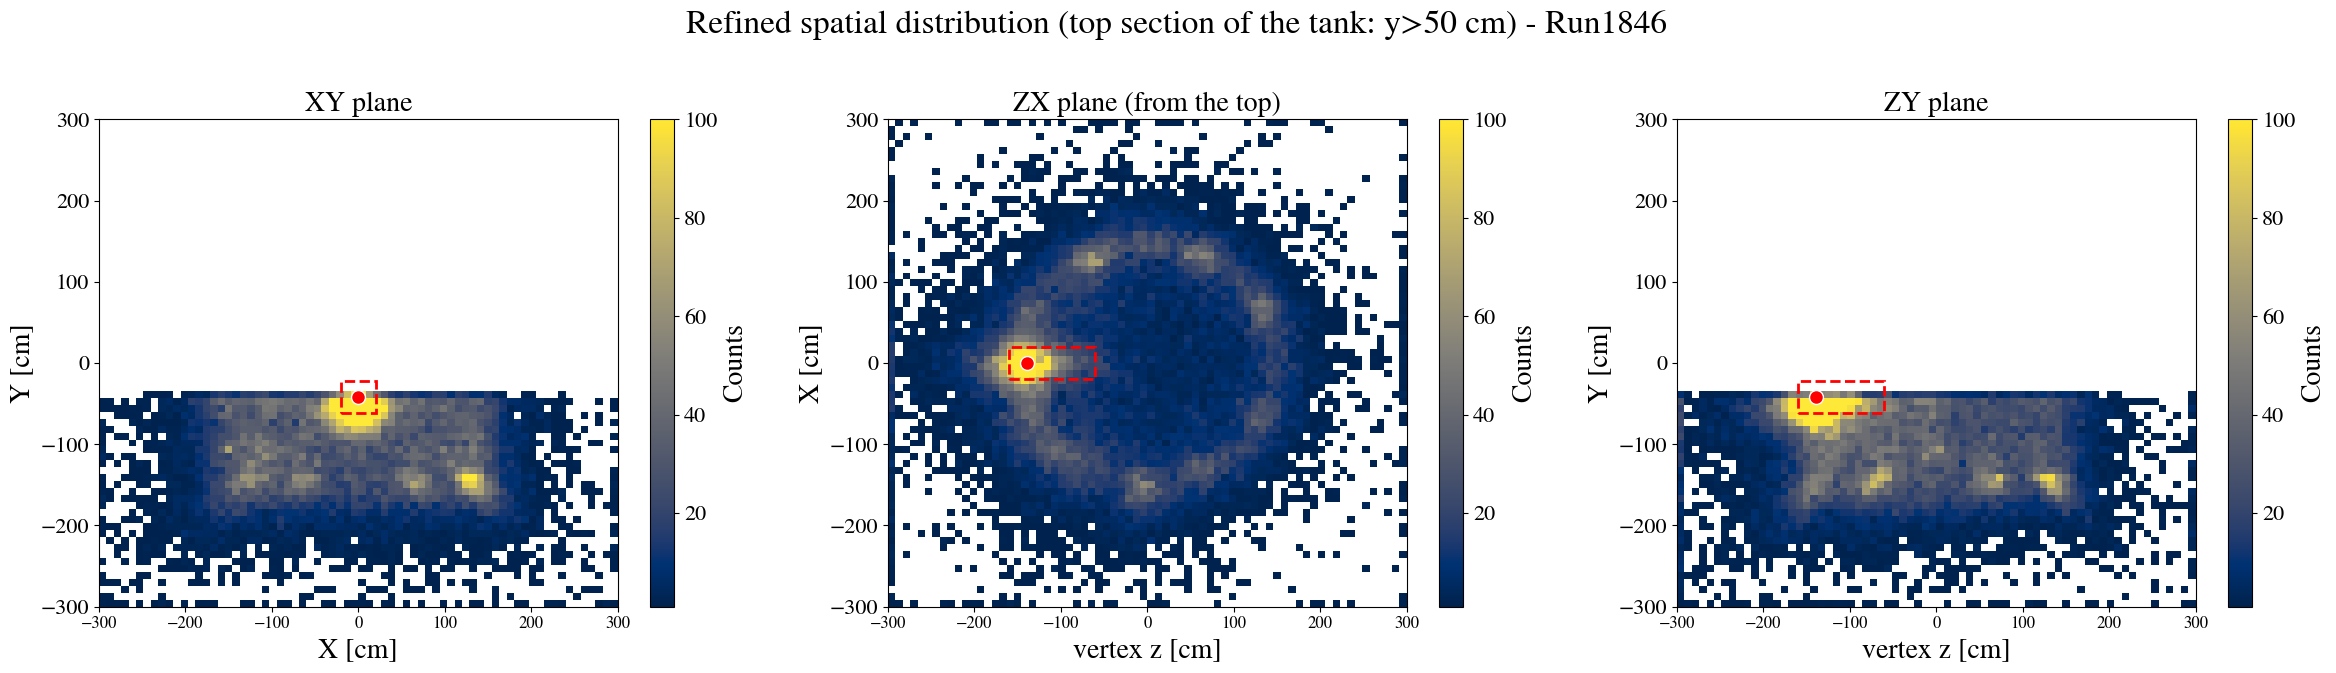

In [34]:
tank_limit = 300 

mask_refined = (df_final['fit_success'] == True) & \
               (df_final["chi2_ndof"] < 5) & \
               (df_final["v_y_fine"] < -40) 

df_clean = df_final[mask_refined].copy()

fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 
x_lims, y_lims, z_lims = [-20, 20], [-62, -22], [-160, -60]
box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

# --- CONFIGURACIÓN DE COLORBAR ---
# Ajusta este valor al máximo que veías en tu plot anterior (ej. ~100 o 150)
# para que la densidad de color sea comparable.
VMAX_DENSITY = 100 

# XY plane 
im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], 
                    bins=70, cmap='cividis', cmin=1, 
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
axs[0].add_patch(patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume'))
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# ZX plane
im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], 
                    bins=70, cmap='cividis', cmin=1,
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
axs[1].add_patch(patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style))
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# ZY plane 
im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], 
                    bins=70, cmap='cividis', cmin=1,
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
axs[2].add_patch(patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style))
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

# force tank limits
for ax in axs:
    ax.set_xlim(-tank_limit, tank_limit)
    ax.set_ylim(-tank_limit, tank_limit)

plt.suptitle(f"Refined spatial distribution (top section of the tank: y>50 cm) - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()

In [35]:
fv_mask = (df_final['fit_success'] == True) & \
          (df_final['v_x_fine'] >= x_lims[0]) & (df_final['v_x_fine'] <= x_lims[1]) & \
          (df_final['v_y_fine'] >= y_lims[0]) & (df_final['v_y_fine'] <= y_lims[1]) & \
          (df_final['v_z_fine'] >= z_lims[0]) & (df_final['v_z_fine'] <= z_lims[1]) & \
          (df_final["chi2_ndof"] < 5)

df_fv = df_final[fv_mask].copy()
df_fv['t_ms'] = df_fv['t_window_start_rel_ns'] / 1e6

print(f"Total candidates in fiducial volume: {len(df_fv)}")

Total candidates in fiducial volume: 3269


# WE SAVE THE FILTERED CLUSTER CANDIDATES!

In [36]:
output_dir = "/scratch/elena/9Li/results/filtered_cluster_candidates"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

filename = f"{output_dir}/df_fv_run{run_number}_n{len(df_fv)}.pkl"

df_fv['run_number'] = run_number  
df_fv.to_pickle(filename)

print(f"Run {run_number} save!")
print(f"File name: {filename}")
print(f"Filtered number of cluster candidates saved: {len(df_fv)}")

Run 1846 save!
File name: /scratch/elena/9Li/results/filtered_cluster_candidates/df_fv_run1846_n3269.pkl
Filtered number of cluster candidates saved: 3269


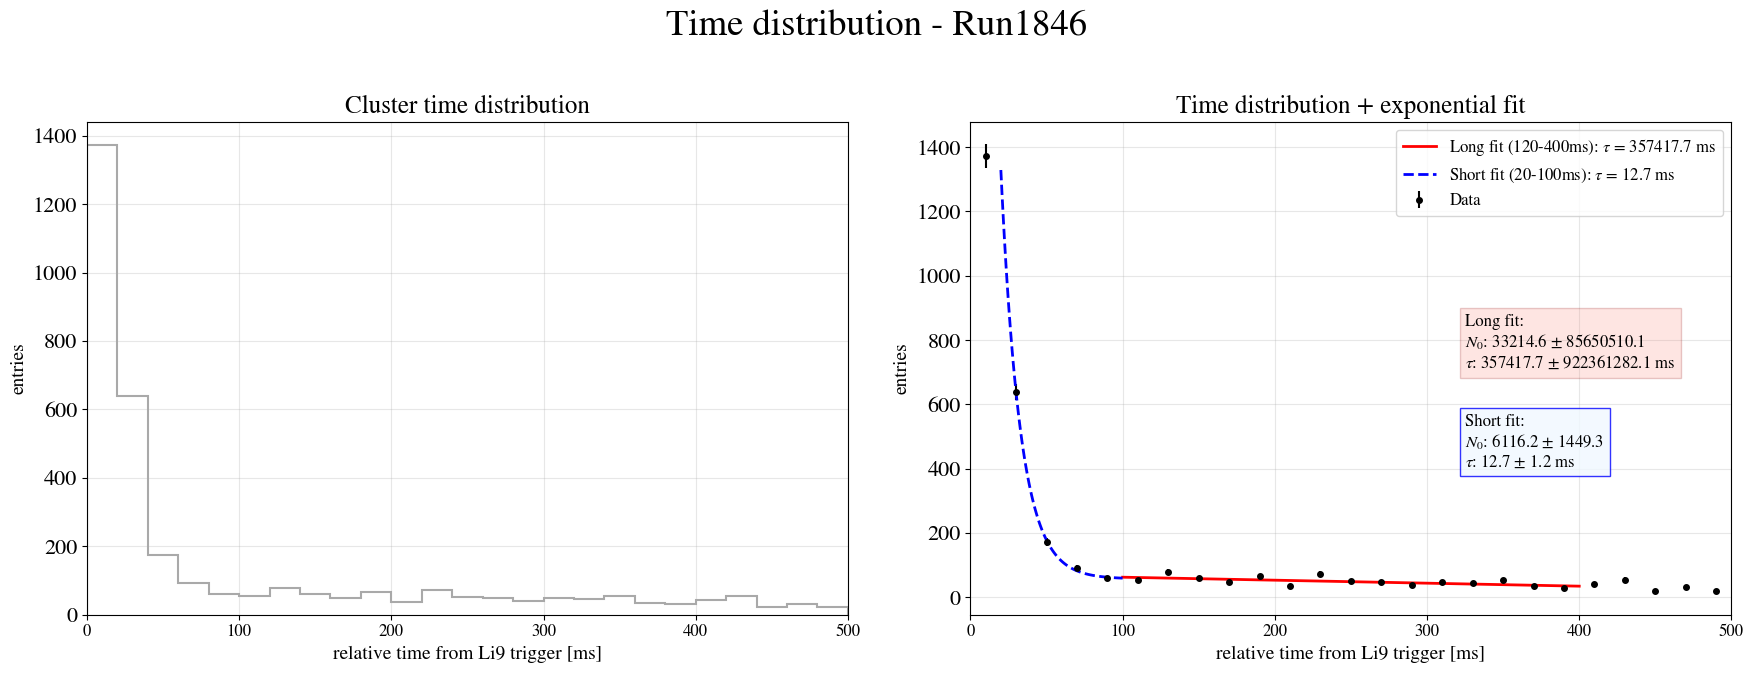

Resultado del ajuste: tau = 357417.68 +/- 922361282.06 ms


In [37]:
from scipy.optimize import curve_fit

bin_width = 20
full_bins = np.arange(0, 500 + bin_width, bin_width)
counts, edges = np.histogram(df_fv['t_ms'], bins=full_bins)
centers = (edges[:-1] + edges[1:]) / 2


def decay_func(t, N0, tau, C):
    return N0 * np.exp(-t / tau) + C

mask_fit = (centers >= 100) & (centers <= 400)
x_fit = centers[mask_fit]
y_fit = counts[mask_fit]

mask_short = (centers >= 20) & (centers <= 100)
x_short = centers[mask_short]
y_short = counts[mask_short]


# Estimación inicial: [N0, tau, C]
p0 = [y_fit.max(), 250.0, y_fit.min()]
p0_short = [y_short.max(), 14.0, y_short.min()]

# Ejecución del ajuste
popt, pcov = curve_fit(decay_func, x_fit, y_fit, p0=p0, sigma=np.sqrt(y_fit + 1))
perr = np.sqrt(np.diag(pcov))

popt_s, pcov_s = curve_fit(decay_func, x_short, y_short, p0=p0_short, sigma=np.sqrt(y_short + 1))
perr_s = np.sqrt(np.diag(pcov_s))


#PLOTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.hist(df_fv['t_ms'], bins=full_bins, histtype='step', color='darkgray', lw=1.5)
ax1.set_title("Cluster time distribution", fontsize=18)
ax1.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax1.set_ylabel("entries", fontsize=14)
ax1.set_xlim(0, 500)
ax1.grid(alpha=0.3)


ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=4, label='Data')
t_fine = np.linspace(100, 400, 200)
ax2.plot(t_fine, decay_func(t_fine, *popt), 'r-', lw=2, label=f'Long fit (120-400ms): $\\tau$ = {popt[1]:.1f} ms')
t_short_plot = np.linspace(20, 100, 100)
ax2.plot(t_short_plot, decay_func(t_short_plot, *popt_s), 'b--', lw=2, label=f'Short fit (20-100ms): $\\tau$ = {popt_s[1]:.1f} ms')


res_text = (f"Long fit:\n"
            f"$N_0$: {popt[0]:.1f} ± {perr[0]:.1f}\n"
            f"$\\tau$: {popt[1]:.1f} ± {perr[1]:.1f} ms")
        

res_short = (f"Short fit:\n"
             f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
             f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax2.text(0.65, 0.5, res_text, transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='salmon', alpha=0.2, edgecolor='darkred'))
ax2.text(0.65, 0.30, res_short, transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))


ax2.set_title("Time distribution + exponential fit", fontsize=18)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax2.set_ylabel("entries", fontsize=14)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

plt.suptitle(f"Time distribution - Run{run_number}")
plt.tight_layout()
plt.show()

print(f"Resultado del ajuste: tau = {popt[1]:.2f} +/- {perr[1]:.2f} ms")

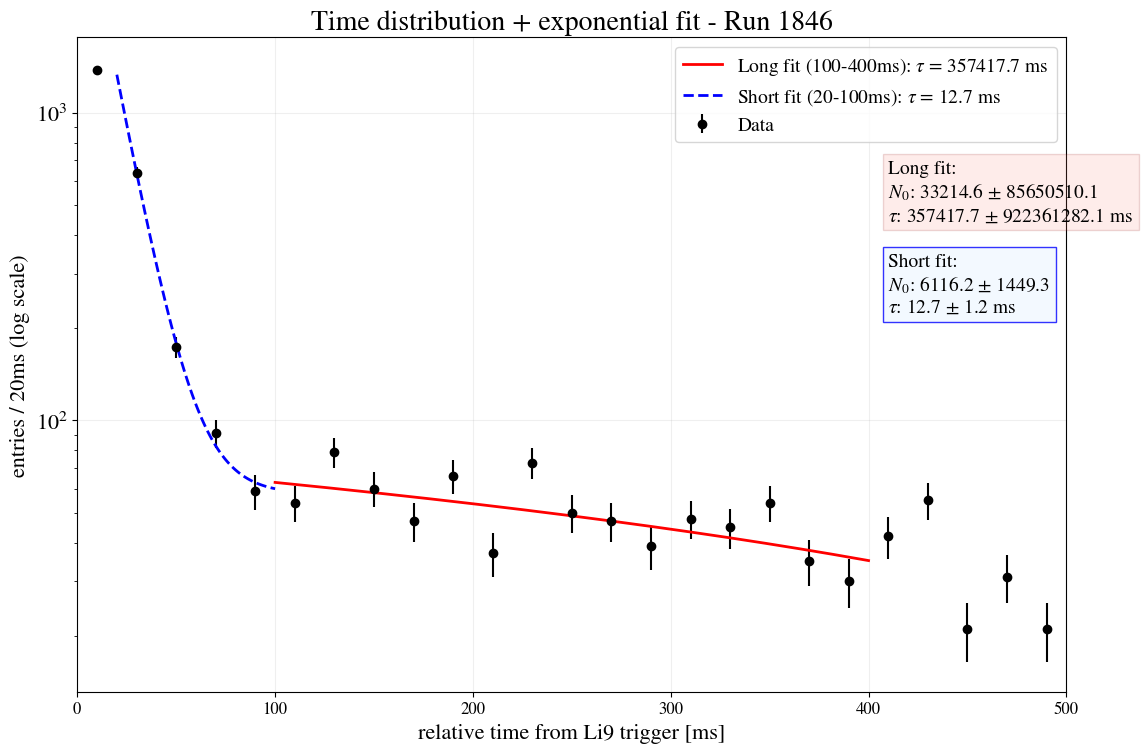

Resultado final Li9: tau = 357417.68 +/- 922361282.06 ms
Resultado final B12: tau = 12.73 +/- 1.23 ms


In [38]:

fig, ax2 = plt.subplots(figsize=(12, 8))

# Datos experimentales (todos los puntos)
ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')

t_fine = np.linspace(100, 400, 200)
ax2.plot(t_fine, decay_func(t_fine, *popt), 'r-', lw=2, label=f'Long fit (100-400ms): $\\tau$ = {popt[1]:.1f} ms')

t_short_plot = np.linspace(20, 100, 100)
ax2.plot(t_short_plot, decay_func(t_short_plot, *popt_s), 'b--', lw=2, label=f'Short fit (20-100ms): $\\tau$ = {popt_s[1]:.1f} ms')

res_text = (f"Long fit:\n"
            f"$N_0$: {popt[0]:.1f} ± {perr[0]:.1f}\n"
            f"$\\tau$: {popt[1]:.1f} ± {perr[1]:.1f} ms")
        
res_short = (f"Short fit:\n"
             f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
             f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax2.text(0.82, 0.72, res_text, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='salmon', alpha=0.15, edgecolor='darkred'))
ax2.text(0.82, 0.58, res_short, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))


ax2.set_title(f"Time distribution + exponential fit - Run {run_number}", fontsize=20)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=16)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=16)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=14, loc='upper right')
ax2.grid(alpha=0.2)

plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"Resultado final Li9: tau = {popt[1]:.2f} +/- {perr[1]:.2f} ms")
print(f"Resultado final B12: tau = {popt_s[1]:.2f} +/- {perr_s[1]:.2f} ms")

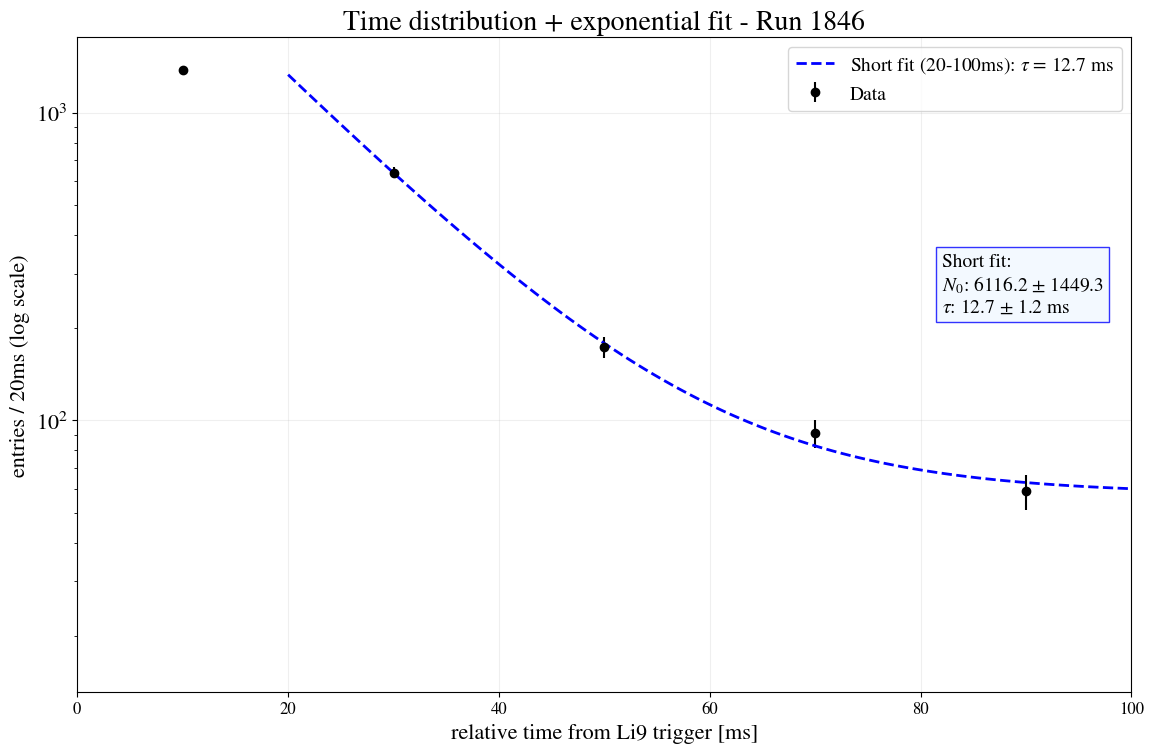

In [39]:

fig, ax2 = plt.subplots(figsize=(12, 8))

# Datos experimentales (todos los puntos)
ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')


t_short_plot = np.linspace(20, 100, 100)
ax2.plot(t_short_plot, decay_func(t_short_plot, *popt_s), 'b--', lw=2, label=f'Short fit (20-100ms): $\\tau$ = {popt_s[1]:.1f} ms')

        
res_short = (f"Short fit:\n"
             f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
             f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax2.text(0.82, 0.58, res_short, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))


ax2.set_title(f"Time distribution + exponential fit - Run {run_number}", fontsize=20)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=16)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=16)
ax2.set_xlim(0, 100)
ax2.legend(fontsize=14, loc='upper right')
ax2.grid(alpha=0.2)

plt.yscale("log")
plt.tight_layout()
plt.show()


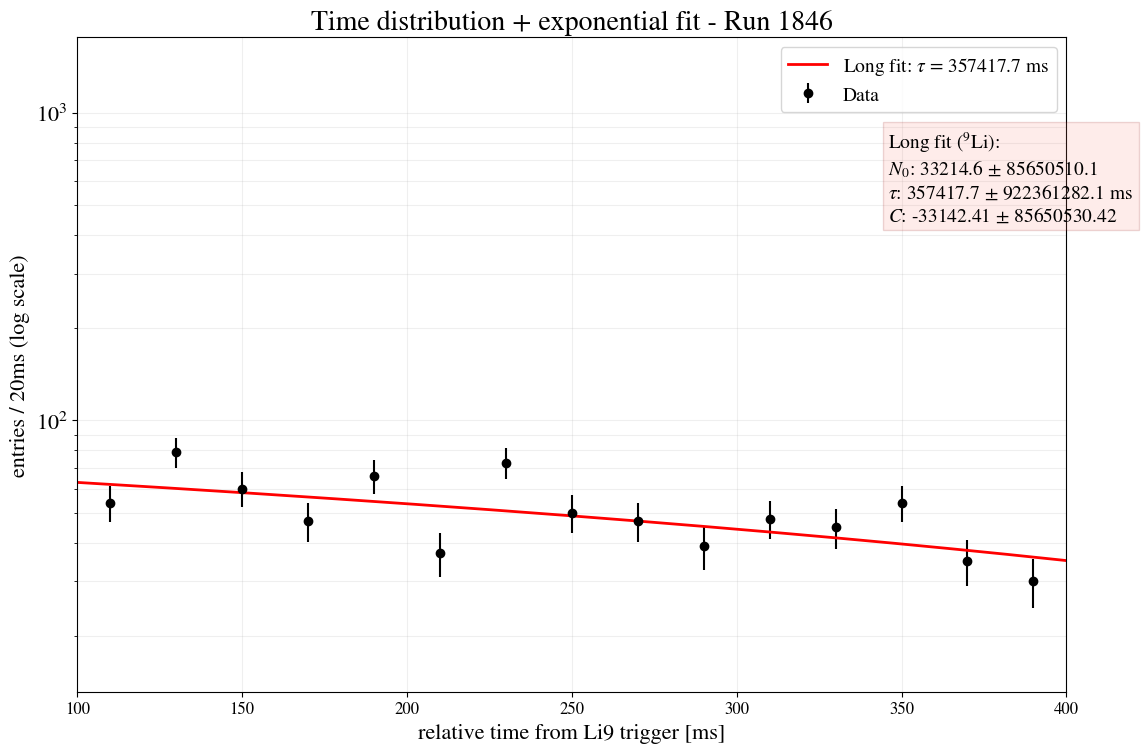

In [40]:
fig, ax2 = plt.subplots(figsize=(12, 8))

ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')

t_plot = np.linspace(100, 400, 200)
ax2.plot(t_plot, decay_func(t_plot, *popt), 'r-', lw=2, label=f'Long fit: $\\tau$ = {popt[1]:.1f} ms')

res_text = (f"Long fit ($^{9}$Li):\n"
            f"$N_0$: {popt[0]:.1f} ± {perr[0]:.1f}\n"
            f"$\\tau$: {popt[1]:.1f} ± {perr[1]:.1f} ms\n"
            f"$C$: {popt[2]:.2f} ± {perr[2]:.2f}")

ax2.text(0.82, 0.72, res_text, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='salmon', alpha=0.15, edgecolor='darkred'))


ax2.set_title(f"Time distribution + exponential fit - Run {run_number}", fontsize=20)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=16)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=16)


ax2.set_xlim(100, 400) 
ax2.set_yscale("log")
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend(fontsize=14)

plt.tight_layout()
plt.show()

# high statistics!

In [41]:
import glob


pattern = '/scratch/elena/9Li/results/filtered_cluster_candidates/df_fv_run1*.pkl'
all_files = glob.glob(pattern)
all_files.sort()

if not all_files:
    raise FileNotFoundError(f"No files found matching: {pattern}")

print(f"Found {len(all_files)} files. Loading...")
df_list = [pd.read_pickle(f) for f in all_files]
df_combined = pd.concat(df_list, ignore_index=True)


time_col = 't_ms' 

print(f"Using column '{time_col}' for time distribution.")
print(f"Total candidates combined: {len(df_combined)}")

Found 2 files. Loading...
Using column 't_ms' for time distribution.
Total candidates combined: 6346


In [46]:
# --- 1. Define the Fitting Function ---
def decay_func(t, N0, tau, background):
    return N0 * np.exp(-t / tau) + background

# --- 2. Create the Histogram Data ---
bin_width =20
bins = np.arange(0, 500 + bin_width, bin_width)

# We use the combined dataframe and the time column you identified ('t_ms')
counts, edges = np.histogram(df_combined['t_ms'], bins=bins)
centers = (edges[:-1] + edges[1:]) / 2


#filter out bins with 0 counts to avoid log errors and division by zero
mask = counts > 0
x_data = centers[mask]
y_data = counts[mask]

# Poisson statistical error
y_err = np.sqrt(y_data)

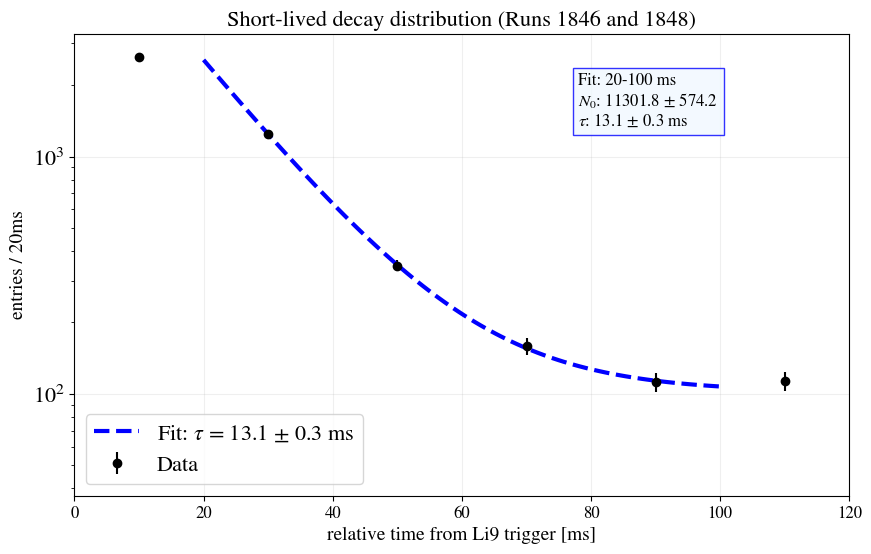

In [47]:
mask_s = (x_data >= 20) & (x_data <= 100)


popt_s, pcov_s = curve_fit(decay_func, x_data[mask_s], y_data[mask_s], 
                           p0=[max(y_data), 29.1, 30], sigma=y_err[mask_s])

perr_s = np.sqrt(np.diag(pcov_s))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')

t_s_plot = np.linspace(20, 100, 100)
ax1.plot(t_s_plot, decay_func(t_s_plot, *popt_s), 'b--', lw=3, 
         label=f'Fit: $\\tau$ = {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms')

res_s = ("Fit: 20-100 ms\n"
         f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
         f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax1.text(0.65, 0.80, res_s, transform=ax1.transAxes, fontsize=12,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))

ax1.set_title("Short-lived decay distribution (Runs 1846 and 1848)", fontsize=16)
ax1.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax1.set_ylabel(f"entries / {bin_width}ms", fontsize=14)
ax1.set_xlim(0, 120)
ax1.set_yscale("log")
ax1.legend()
plt.grid(alpha=0.2)
plt.show()

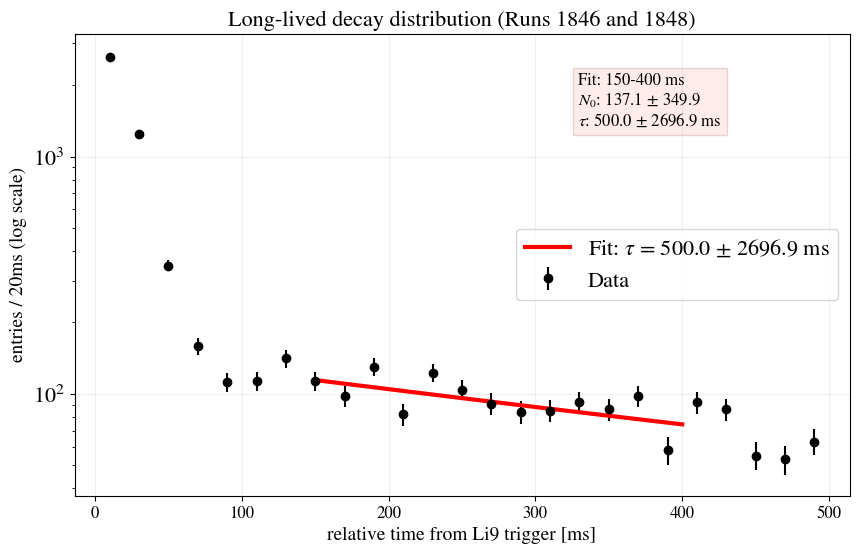

9Li Result: 500.00 +/- 2696.92 ms


In [48]:

mask_l = (x_data >= 150) & (x_data <= 400)
# Bounds: ([N_min, Tau_min, BG_min], [N_max, Tau_max, BG_max])
popt_l, pcov_l = curve_fit(decay_func, x_data[mask_l], y_data[mask_l], 
                           p0=[50, 257.0, 25], 
                           bounds=([0, 100, 0], [np.inf, 500, np.inf]),
                           sigma=y_err[mask_l])
perr_l = np.sqrt(np.diag(pcov_l))

fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')

t_l_plot = np.linspace(150, 400, 100)
ax2.plot(t_l_plot, decay_func(t_l_plot, *popt_l), 'r-', lw=3, 
         label=f'Fit: $\\tau$ = {popt_l[1]:.1f} ± {perr_l[1]:.1f} ms')

res_l = ("Fit: 150-400 ms\n"
         f"$N_0$: {popt_l[0]:.1f} ± {perr_l[0]:.1f}\n"
         f"$\\tau$: {popt_l[1]:.1f} ± {perr_l[1]:.1f} ms")

ax2.text(0.65, 0.80, res_l, transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='salmon', alpha=0.15, edgecolor='darkred'))

ax2.set_title("Long-lived decay distribution (Runs 1846 and 1848)", fontsize=16)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=14)
#ax2.set_xlim(0, 500)
#ax2.set_ylim(10, max(counts[centers > 100])*2) # Focus on the lower intensity tail
ax2.set_yscale("log")
ax2.legend()
plt.grid(alpha=0.2)
plt.show()

print(f"9Li Result: {popt_l[1]:.2f} +/- {perr_l[1]:.2f} ms")

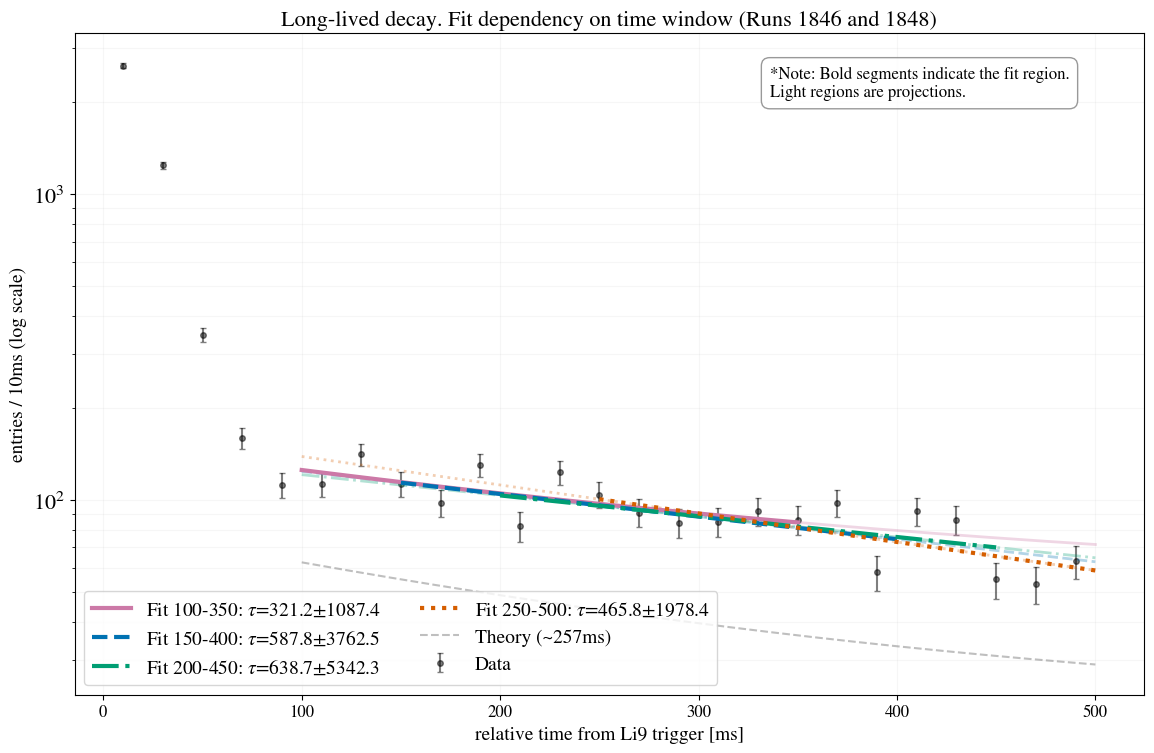

In [50]:
fig, ax2 = plt.subplots(figsize=(12, 8))

ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=4, label='Data', alpha=0.5, capsize=2)

fit_configs = [
    {"range": (100, 350)},
    {"range": (150, 400)},
    {"range": (200, 450)},
    {"range": (250, 500)}
]

colors = ["#CC79A7", "#0072B2", "#009E73", "#D55E00"]
line_styles = ["-", "--", "-.", ":"]

t_full = np.linspace(100, 500, 500) # Rango total para la proyección

for i, cfg in enumerate(fit_configs):
    t_min, t_max = cfg["range"]
    mask = (x_data >= t_min) & (x_data <= t_max)
    
    #fit
    popt, pcov = curve_fit(decay_func, x_data[mask], y_data[mask], 
                           p0=[50, 257.0, 25], 
                           bounds=([0, 50, 0], [np.inf, 1000, np.inf]),
                           sigma=y_err[mask])
    perr = np.sqrt(np.diag(pcov))
    
    # --- DIBUJO EN DOS PARTES ---
    # 1. Línea sólida GRUESA (solo en el rango del fit)
    t_fit_range = np.linspace(t_min, t_max, 100)
    label_str = f'Fit {t_min}-{t_max}: $\\tau$={popt[1]:.1f}±{perr[1]:.1f}'
    ax2.plot(t_fit_range, decay_func(t_fit_range, *popt), color=colors[i], lw=3, linestyle=line_styles[i], label=label_str, zorder=5)
    
    # 2. Línea punteada FINA (proyección en el resto del rango)
    # Dibujamos la línea en todo el rango pero con alpha bajo y estilo punteado
    ax2.plot(t_full, decay_func(t_full, *popt), color=colors[i], lw=2, linestyle=line_styles[i], alpha=0.3, zorder=4)

ref_line = 35 * np.exp(-(t_full - 150) / 257.0) + 20 
ax2.plot(t_full, ref_line, color='gray', ls="--", alpha=0.5, label='Theory (~257ms)')

ax2.set_yscale("log")
#ax2.set_xlim(0, 510)
#ax2.set_ylim(10,500)
ax2.set_title("Long-lived decay. Fit dependency on time window (Runs 1846 and 1848)", fontsize=16)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax2.set_ylabel("entries / 10ms (log scale)", fontsize=14)
ax2.legend(loc='lower left', fontsize=14, ncol=2)
ax2.grid(True, which='both', alpha=0.1)


explanation_text = (
    "*Note: Bold segments indicate the fit region.\n"
    "Light regions are projections."
)

ax2.text(0.65, 0.95, explanation_text, transform=ax2.transAxes, 
         fontsize=12, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))


plt.tight_layout()
plt.show()